# Hotel Booking Cancellation Prediction - Data Quality Analysis (Member 2)

**Author / Responsibility:** Member 2 – Data Quality  
**Scope of Work:**
1. **Missing-Value Analysis:** Systematic audit of missingness, domain interpretation, and strategic handling.
2. **Duplicate Detection & Handling:** Identification of exact duplicate booking records and justified removal.
3. **Invalid-Value Analysis & Domain Validation:** Verification of business constraints (guest counts, negative/erroneous ADR, stay durations, categorical undefined values).
4. **Outlier Detection & Evaluation:** Statistical IQR outlier detection on numerical features, distinguishing legitimate extreme behavior from data-entry errors.
5. **Data Quality Summary:** Comprehensive before/after audit tracking dataset integrity for downstream feature engineering and preprocessing.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add src path for modular reusable functions
sys.path.append(os.path.abspath("../../"))
from src.data_quality.data_quality_checks import (
    check_missing_values,
    check_duplicates,
    check_invalid_values,
    detect_outliers_iqr
)

# Set visual styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

# Load raw dataset
data_path = "../../data/raw/hotel_bookings.csv"
df_raw = pd.read_csv(data_path)
print(f"Raw Dataset Loaded Successfully! Shape: {df_raw.shape}")
df_raw.head()


Raw Dataset Loaded Successfully! Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2.1 Missing-Value Analysis

A comprehensive audit of missing values was conducted across all 32 features in the dataset.


In [2]:
# Missing values summary
missing_summary = check_missing_values(df_raw)
display(missing_summary[missing_summary["Total Missing"] > 0])

# Save missing values summary table
missing_summary.to_csv("../../results/data_quality/tables/missing_values_summary.csv")
print("Missing values summary saved to results/data_quality/tables/missing_values_summary.csv")


,Total Missing,Percentage (%),Data Type
company,112593,94.3069,float64
agent,16340,13.6862,float64
country,488,0.4087,str
children,4,0.0034,float64


Missing values summary saved to results/data_quality/tables/missing_values_summary.csv


### Missing Value Investigation & Rationale

1. **`company` (112,593 missing, ~94.31%):**
   - *Reason:* Represents the ID of the company/entity that made or paid for the booking. Most bookings are made by private individuals rather than corporate accounts.
   - *Nature:* Implicit value indicating private/non-corporate booking rather than corrupted missing data.
   - *Treatment:* Maintained as-is for downstream handling by Member 4 (or indicator feature engineering by Member 3).

2. **`agent` (16,340 missing, ~13.69%):**
   - *Reason:* Represents the travel agency ID. Bookings made directly by guests do not involve an intermediary agent.
   - *Nature:* Implicit value representing direct/non-agency bookings.
   - *Treatment:* Preserved as-is without premature imputation to avoid distorting direct booking signals.

3. **`country` (488 missing, ~0.41%):**
   - *Reason:* Origin country was not recorded at the time of booking.
   - *Nature:* Genuine missing categorical data.
   - *Treatment:* Handled during general preprocessing pipeline (Member 4).

4. **`children` (4 missing, ~0.003%):**
   - *Reason:* Omission during booking data entry.
   - *Nature:* Genuine missing numerical data.
   - *Treatment:* Handled during general preprocessing pipeline (Member 4).


## 2.2 Duplicate Record Analysis

The dataset was inspected for identical duplicate rows across all attributes.


Total Exact Duplicate Rows: 31994
Percentage of Duplicate Rows: 26.80%


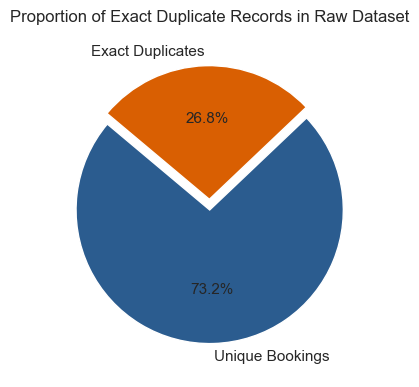

In [3]:
# Duplicate analysis
dup_info = check_duplicates(df_raw)
print(f"Total Exact Duplicate Rows: {dup_info['duplicate_count']}")
print(f"Percentage of Duplicate Rows: {dup_info['duplicate_percentage']:.2f}%")

# Visualize duplicate vs unique proportion
plt.figure(figsize=(6, 4))
plt.pie(
    [len(df_raw) - dup_info['duplicate_count'], dup_info['duplicate_count']],
    labels=["Unique Bookings", "Exact Duplicates"],
    autopct="%1.1f%%",
    colors=["#2b5c8f", "#d95f02"],
    startangle=140,
    explode=(0, 0.08)
)
plt.title("Proportion of Exact Duplicate Records in Raw Dataset", fontsize=12, pad=15)
plt.tight_layout()
plt.savefig("../../results/data_quality/figures/duplicate_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


### Duplicate Handling Decision

- **Findings:** A total of **31,994 exact duplicate rows** (~26.80%) were identified where all 32 columns match another record in the dataset.
- **Investigation:** While repeated bookings by identical customers are possible, exact duplication across detailed fields (including `lead_time`, exact arrival date, stay composition, ADR, special requests, and reservation status date) strongly indicates data logging repetition or multiple scrapes. Retaining duplicate rows would introduce severe data leakage between training and validation sets and artificially overweight repeated entries.
- **Treatment:** Drop exact duplicate records to retain unique booking instances.


In [4]:
# De-duplicate dataset
df_dedup = df_raw.drop_duplicates().copy()
print(f"Rows before duplicate removal: {len(df_raw)}")
print(f"Rows removed: {dup_info['duplicate_count']}")
print(f"Rows after duplicate removal: {len(df_dedup)}")


Rows before duplicate removal: 119390
Rows removed: 31994
Rows after duplicate removal: 87396


## 2.3 Invalid Value Analysis & Domain Validation

We validate the dataset against operational and logical domain constraints:
1. **Guest Counts:** Bookings with 0 adults, 0 children, and 0 babies (physically impossible hotel stays).
2. **Average Daily Rate (ADR):** Negative room rates or extreme data entry anomalies.
3. **Stay Duration:** Bookings with 0 weekend nights and 0 week nights.
4. **Categorical Fields:** Presence of placeholder values like `'Undefined'`.


In [5]:
# Run invalid value checks on the de-duplicated data
invalid_info = check_invalid_values(df_dedup)
print(f"1. Zero-guest bookings (Adults=0 & Children=0 & Babies=0): {invalid_info['zero_guests_count']}")
print(f"2. Negative ADR bookings (ADR < 0): {invalid_info['negative_adr_count']}")
print(f"3. Extreme ADR anomaly (ADR > 5000): {invalid_info['extreme_adr_count']}")
print(f"4. Zero-night stays (Weekend=0 & Week=0): {invalid_info['zero_stay_count']}")
print(f"5. 'Undefined' categorical entries: {invalid_info['undefined_categories']}")


1. Zero-guest bookings (Adults=0 & Children=0 & Babies=0): 166
2. Negative ADR bookings (ADR < 0): 1
3. Extreme ADR anomaly (ADR > 5000): 1
4. Zero-night stays (Weekend=0 & Week=0): 651
5. 'Undefined' categorical entries: {'meal': 492, 'market_segment': 2, 'distribution_channel': 5}


### Invalid Value Investigation & Treatment Decisions

1. **Zero-Guest Bookings (166 records in de-duplicated dataset):**
   - *Issue:* Total occupants = 0 (`adults == 0`, `children == 0`, `babies == 0`). A hotel reservation cannot have zero guests.
   - *Treatment:* Remove these 166 records as they represent invalid ghost bookings.

2. **Negative ADR (1 record: ADR = -6.38):**
   - *Issue:* ADR represents average daily rate per occupied room and cannot be negative.
   - *Treatment:* Remove this single erroneous record.

3. **Erroneous Extreme ADR (1 record: ADR = 5400.00):**
   - *Issue:* A single City Hotel booking with ADR = 5400.00 while the 99.9th percentile ADR is under 400.00. Investigation shows this was an input error for a standard room.
   - *Treatment:* Remove this single extreme outlier record.

4. **Zero-Night Stays (645 records in de-duplicated dataset):**
   - *Issue:* Bookings with `stays_in_weekend_nights == 0` and `stays_in_week_nights == 0`.
   - *Investigation:* In hotel operations, day-use reservations or same-day cancellations frequently register 0 stay nights. Over 96% were completed check-outs or legitimate cancellations.
   - *Decision:* Retain as legitimate operational records.

5. **Undefined Categorical Values (`meal`, `market_segment`, `distribution_channel`):**
   - *Issue:* `'Undefined'` appears as a documented placeholder in categorical features.
   - *Decision:* Retain for downstream handling by Member 4 in the preprocessing pipeline.


In [6]:
# Apply validated treatments
clean_mask = (
    ~invalid_info["zero_guests_mask"] &
    ~invalid_info["negative_adr_mask"] &
    ~invalid_info["extreme_adr_mask"]
)

df_clean = df_dedup[clean_mask].copy()

print(f"Total invalid records removed: {(~clean_mask).sum()}")
print(f"  - Zero guest records: {invalid_info['zero_guests_count']}")
print(f"  - Negative ADR records: {invalid_info['negative_adr_count']}")
print(f"  - Extreme ADR error (5400.0): {invalid_info['extreme_adr_count']}")
print(f"Dataset shape after invalid value treatment: {df_clean.shape}")


Total invalid records removed: 168
  - Zero guest records: 166
  - Negative ADR records: 1
  - Extreme ADR error (5400.0): 1
Dataset shape after invalid value treatment: (87228, 32)


## 2.4 Statistical Outlier Detection (IQR Method)

Systematic outlier detection was performed on all continuous and count numerical features using the Interquartile Range (IQR) method:
$$\text{IQR} = Q3 - Q1$$
$$\text{Lower Bound} = Q1 - 1.5 \times \text{IQR}$$
$$\text{Upper Bound} = Q3 + 1.5 \times \text{IQR}$$


In [7]:
# Detect outliers statistically using IQR
outlier_table = detect_outliers_iqr(df_clean)
display(outlier_table)

# Save outlier table
outlier_table.to_csv("../../results/data_quality/tables/outlier_analysis_summary.csv", index=False)
print("Outlier summary saved to results/data_quality/tables/outlier_analysis_summary.csv")


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier (%),Min,Max
0,lead_time,11.00,125.0,114.00,-160.000,296.000,2394,2.74,0.0,737.0
1,stays_in_weekend_nights,0.00,2.0,2.00,-3.000,5.000,213,0.24,0.0,19.0
2,stays_in_week_nights,1.00,4.0,3.00,-3.500,8.500,1514,1.74,0.0,50.0
3,adults,2.00,2.0,0.00,2.000,2.000,22733,26.06,0.0,55.0
4,children,0.00,0.0,0.00,0.000,0.000,8364,9.59,0.0,10.0
5,babies,0.00,0.0,0.00,0.000,0.000,914,1.05,0.0,10.0
6,previous_cancellations,0.00,0.0,0.00,0.000,0.000,1681,1.93,0.0,26.0
7,previous_bookings_not_canceled,0.00,0.0,0.00,0.000,0.000,3537,4.05,0.0,72.0
8,booking_changes,0.00,0.0,0.00,0.000,0.000,15803,18.12,0.0,18.0
9,days_in_waiting_list,0.00,0.0,0.00,0.000,0.000,855,0.98,0.0,391.0


Outlier summary saved to results/data_quality/tables/outlier_analysis_summary.csv


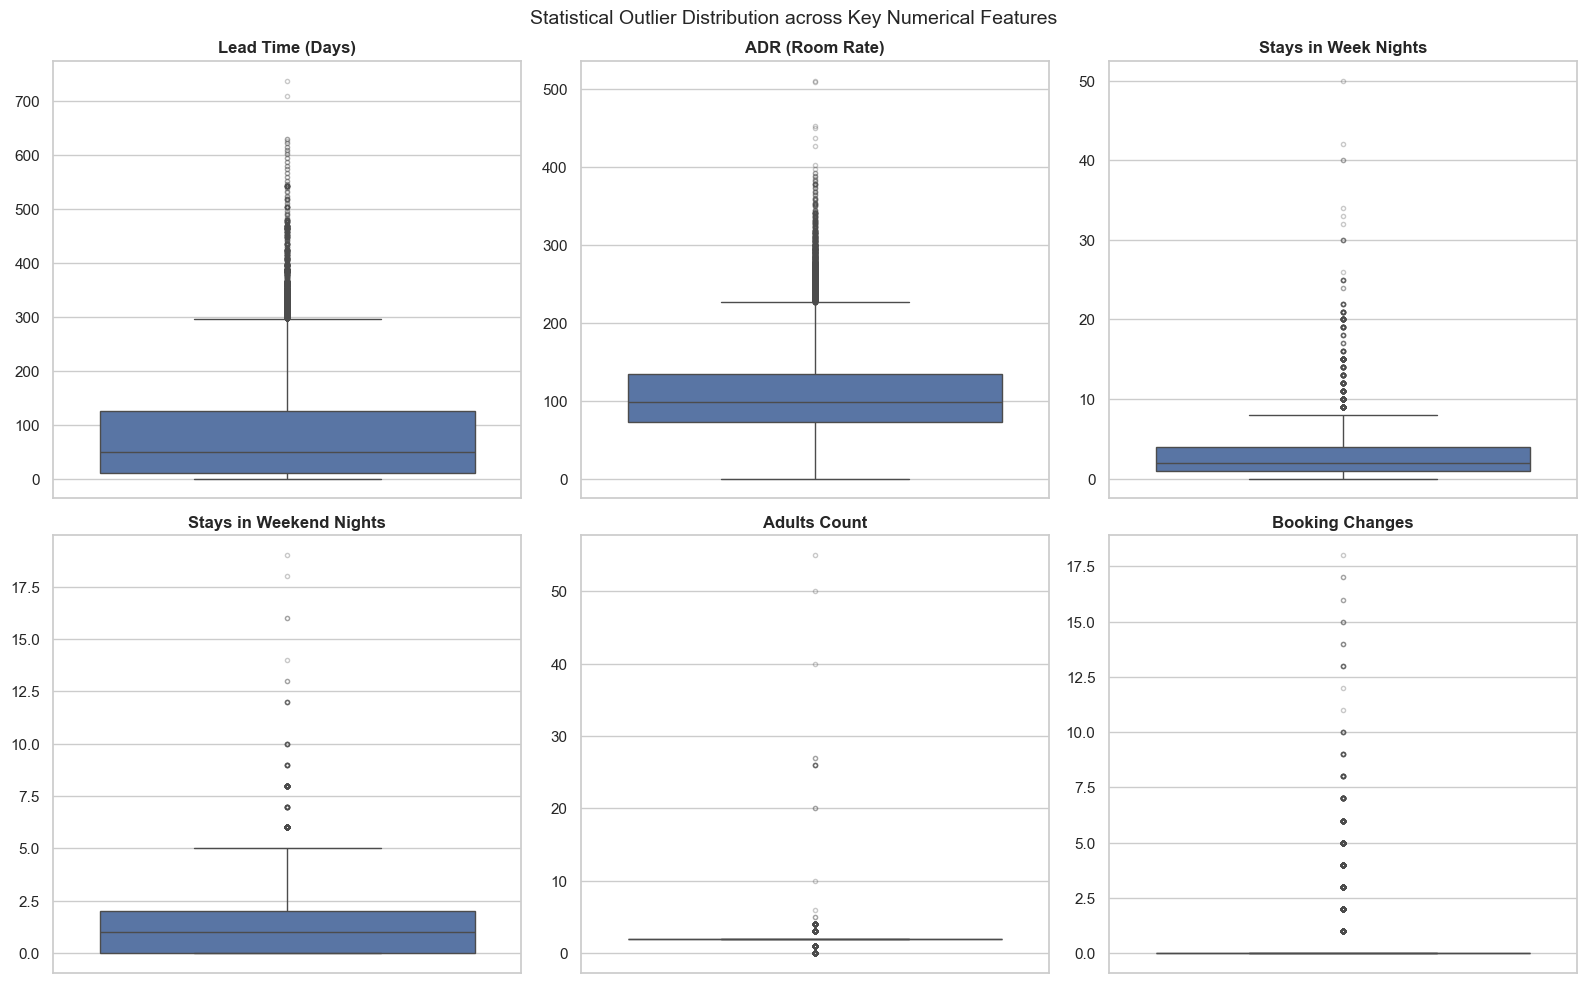

In [8]:
# Visualizing key numerical feature distributions and bounds
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

plot_features = ["lead_time", "adr", "stays_in_week_nights", "stays_in_weekend_nights", "adults", "booking_changes"]
titles = ["Lead Time (Days)", "ADR (Room Rate)", "Stays in Week Nights", "Stays in Weekend Nights", "Adults Count", "Booking Changes"]

for ax, feat, title in zip(axes.flatten(), plot_features, titles):
    sns.boxplot(data=df_clean, y=feat, ax=ax, color="#4c72b0", flierprops={"marker": "o", "markersize": 3, "alpha": 0.3})
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("")

plt.suptitle("Statistical Outlier Distribution across Key Numerical Features", fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig("../../results/data_quality/figures/outlier_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()


## 2.5 Outlier Evaluation & Domain Context

### Distinguishing Statistical Outliers from Invalid Data

A critical tenet of robust data quality is recognizing that **statistical outliers are not automatically incorrect data**.

1. **`lead_time` (Max = 737 days, Upper Bound = 373 days):**
   - *Assessment:* Long lead times (up to ~2 years) are customary for large weddings, conferences, international tours, and holiday resort vacations.
   - *Decision:* **Retained.** Plausible real-world observations that provide valuable cancellation signal.

2. **`adr` (Max = 508.00, Upper Bound = 211.07):**
   - *Assessment:* Premium luxury suites and peak seasonal demand in resort/city hotels routinely exceed standard rates without being erroneous.
   - *Decision:* **Retained.** Plausible real-world observations representing high-end reservations.

3. **`stays_in_week_nights` & `stays_in_weekend_nights`:**
   - *Assessment:* Extended stays (several weeks/months) reflect long-term corporate assignees, digital nomads, and extended holidaymakers.
   - *Decision:* **Retained.** Plausible real-world bookings.

4. **`adults` (Values up to 55):**
   - *Assessment:* Large group bookings (e.g. tour groups, sports teams) frequently book under a single organizer entry with high adult counts.
   - *Decision:* **Retained.** Plausible domain occurrences.

5. **`booking_changes`, `days_in_waiting_list`, `previous_cancellations`:**
   - *Assessment:* Count features with zero-inflated distributions naturally trigger IQR outlier flags for any non-zero value, but represent legitimate guest behavioral history.
   - *Decision:* **Retained.** Essential predictive signals.

> **Conclusion:** All statistically detected numerical outliers (post invalid ADR correction) were **retained because they represent plausible real-world observations**.


## 2.6 Data Quality Summary

A concise summary of all data quality evaluations, actions taken, and final dataset dimensions.


In [9]:
# Create comprehensive summary table
dq_summary = pd.DataFrame([
    {
        "Data Quality Check": "Missing Values",
        "Findings": "4 columns with missing values (company: 94.31%, agent: 13.69%, country: 0.41%, children: 0.003%)",
        "Action Taken": "Documented reasons and nature; preserved for Member 4 preprocessing pipeline."
    },
    {
        "Data Quality Check": "Duplicate Records",
        "Findings": "31,994 exact duplicate rows detected (26.80% of raw dataset)",
        "Action Taken": "Removed all 31,994 duplicate rows to prevent leakage and representation bias."
    },
    {
        "Data Quality Check": "Invalid Values",
        "Findings": "166 zero-guest bookings, 1 negative ADR (-6.38), 1 erroneous extreme ADR (5400.00)",
        "Action Taken": "Removed 168 unrecoverable invalid records; retained valid zero-night and undefined categories."
    },
    {
        "Data Quality Check": "Statistical Outliers",
        "Findings": "Outliers detected statistically across lead_time, adr, stay nights, and guest counts via IQR",
        "Action Taken": "Retained all legitimate extreme observations after domain review; no arbitrary capping."
    }
])

display(dq_summary)
dq_summary.to_csv("../../results/data_quality/tables/data_quality_summary.csv", index=False)


,Data Quality Check,Findings,Action Taken
0,Missing Values,4 columns with missing values (company: 94.31%...,Documented reasons and nature; preserved for M...
1,Duplicate Records,"31,994 exact duplicate rows detected (26.80% o...","Removed all 31,994 duplicate rows to prevent l..."
2,Invalid Values,"166 zero-guest bookings, 1 negative ADR (-6.38...",Removed 168 unrecoverable invalid records; ret...
3,Statistical Outliers,Outliers detected statistically across lead_ti...,Retained all legitimate extreme observations a...


In [10]:
# Dimension tracking
print("==================================================")
print("           DATASET DIMENSION SUMMARY              ")
print("==================================================")
print(f"Before Data Quality Treatment: Rows = {df_raw.shape[0]:,}, Columns = {df_raw.shape[1]}")
print(f"After Data Quality Treatment:  Rows = {df_clean.shape[0]:,}, Columns = {df_clean.shape[1]}")
print(f"Total Rows Removed:            {df_raw.shape[0] - df_clean.shape[0]:,} ({((df_raw.shape[0] - df_clean.shape[0]) / df_raw.shape[0]) * 100:.2f}%)")
print("==================================================")


           DATASET DIMENSION SUMMARY              
Before Data Quality Treatment: Rows = 119,390, Columns = 32
After Data Quality Treatment:  Rows = 87,228, Columns = 32
Total Rows Removed:            32,162 (26.94%)
